## 📦 Step 1: Install & Import Required Libraries


In [1]:
# ── Install (use %pip in Azure ML) ───────────────────────────
%pip install azure-monitor-query azure-identity azure-storage-blob --quiet
%pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet
print('✅ All packages installed!')


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ All packages installed!


In [2]:
# ── Import all libraries ──────────────────────────────────────
import warnings, io, os, json, time, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Azure — DefaultAzureCredential works automatically in Azure ML
from azure.identity import DefaultAzureCredential
from azure.monitor.query import LogsQueryClient, LogsQueryStatus
from azure.storage.blob import BlobServiceClient

# Scikit-learn
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

print('✅ All libraries imported!')
print(f'📅 Run timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')


✅ All libraries imported!
📅 Run timestamp: 2026-04-07 15:24:20


## Step 2: Connect to Azure



In [ ]:
# ============================================================
#  🔑 FILL IN ONLY THESE 2 VALUES
# ============================================================

WORKSPACE_ID = "YOUR_WORKPLACE_ID"
AZURE_CONNECTION_STRING = ""YOUR_CONNECTION_STRING""

# ============================================================

CONTAINER_NAME = "logsgenerated"
WEBSITE_HOST   = "YOUR_WERBSITE"
WEBSITE_SHORT  = "YOUR_WERBSITE_SHORT"

# ── Authenticate using Azure ML managed identity (no keys!) ──
credential  = DefaultAzureCredential()
logs_client = LogsQueryClient(credential)

# ── Blob Storage connection ───────────────────────────────────
blob_service = BlobServiceClient.from_connection_string(AZURE_CONNECTION_STRING)
container_cl = blob_service.get_container_client(CONTAINER_NAME)

# ── Verify blob connection ────────────────────────────────────
try:
    blobs = list(container_cl.list_blobs())
    print('✅ Azure Monitor Log Analytics  → Connected (DefaultAzureCredential)')
    print(f'   Workspace ID : {WORKSPACE_ID}')
    print('✅ Azure Blob Storage           → Connected')
    print(f'   Container    : {CONTAINER_NAME}  ({len(blobs)} existing blobs)')
    print(f'   Website      : {WEBSITE_HOST}')
except Exception as e:
    print(f'❌ Blob Storage connection failed: {e}')
    print('   Check your AZURE_CONNECTION_STRING above.')


✅ Azure Monitor Log Analytics  → Connected (DefaultAzureCredential)
   Workspace ID : c2f0d9d0-4521-45a1-907a-40200046bebe
✅ Azure Blob Storage           → Connected
   Container    : logsgenerated  (10 existing blobs)
   Website      : dummy-website-ai-fbbdbahfgchzftee.centralindia-01.azurewebsites.net


##  Step 3: Extract 16 Features via KQL Query


In [4]:
# ── KQL Query — all 16 features ──────────────────────────
KQL_QUERY = f"""
AppServiceHTTPLogs
| where TimeGenerated >= ago(4d)
| where CsHost contains "{WEBSITE_SHORT}"
| extend is_error      = iff(ScStatus >= 400, 1, 0)
| extend is_5xx        = iff(ScStatus >= 500, 1, 0)
| extend is_401_403    = iff(ScStatus in (401, 403), 1, 0)
| extend is_login      = iff(CsUriStem contains "/login", 1, 0)
| extend is_fail_login = iff(CsUriStem contains "/login" and ScStatus in (401, 403), 1, 0)
| summarize
    request_count           = count(),
    request_rate = round(todouble(count()) / 0.5, 4),
    unique_src_ips          = dcount(CIp),
    requests_per_ip         = round(todouble(count()) / iff(dcount(CIp)==0, 1, dcount(CIp)), 4),
    error_rate              = round(100.0 * countif(is_error==1) / count(), 4),
    server_error_rate       = round(100.0 * countif(is_5xx==1) / count(), 4),
    ratio_401_403           = round(100.0 * countif(is_401_403==1) / count(), 4),
    failed_requests_per_ip  = round(todouble(countif(is_error==1)) / iff(dcount(CIp)==0, 1, dcount(CIp)), 4),
    login_attempts          = countif(is_login==1),
    failed_login_ratio      = round(100.0 * countif(is_fail_login==1) / iff(countif(is_login==1)==0, 1, countif(is_login==1)), 4),
    avg_latency             = round(avg(TimeTaken), 4),
    source_ips              = make_set(CIp, 50),
    source_ports            = make_set(SPort, 50),
    requests_total          = count(),
    failed_requests_rate    = round(100.0 * countif(is_error==1) / count(), 4),
    avg_response_time       = round(avg(TimeTaken), 4)
    by bin(TimeGenerated, 30s)
| order by TimeGenerated asc
"""

# ── Feature column names used for ML ─────────────────────────
FEATURE_COLS = [
    'request_count',          # 1
    'request_rate',           # 2
    'unique_src_ips',         # 3
    'requests_per_ip',        # 4
    'error_rate',             # 5
    'server_error_rate',      # 6
    'ratio_401_403',          # 7
    'failed_requests_per_ip', # 8
    'login_attempts',         # 9
    'failed_login_ratio',     # 10
    'avg_latency',            # 11
    'source_ips_count',       # 12
    'source_ports_count',     # 13
    'requests_total',         # 14
    'failed_requests_rate',   # 15
    'avg_response_time',      # 16
]

print(f'🔄 Querying Azure Monitor Log Analytics...')
print(f'   Workspace  : {WORKSPACE_ID}')
print(f'   Website    : {WEBSITE_HOST}')
print(f'   Window     : Last 14 days  |  10-min bins')
print(f'   Features   : {len(FEATURE_COLS)}')
print()

try:
    t0 = time.time()
    response = logs_client.query_workspace(
        workspace_id = WORKSPACE_ID,
        query        = KQL_QUERY,
        timespan     = timedelta(days=14)
    )
    query_time = time.time() - t0

    if response.status == LogsQueryStatus.SUCCESS \
       and response.tables \
       and len(response.tables[0].rows) > 0:

        table = response.tables[0]
        df_raw = pd.DataFrame(
            data    = table.rows,
            columns = [c for c in table.columns]
        )

        # Derive count-based columns from make_set lists
        df_raw['source_ips_count'] = df_raw['source_ips'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        df_raw['source_ports_count'] = df_raw['source_ports'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )

        print(f'✅ Query SUCCESS  ({query_time:.2f}s)')
        print(f'   Rows returned : {len(df_raw):,}')
        print(f'   Columns       : {list(df_raw.columns)}')
        print()
        print(df_raw[FEATURE_COLS].head(10).to_string())

    else:
        raise ValueError('Empty result set - No data available for this time window.')

except Exception as e:
    print(f'❌ ERROR: KQL query failed!')
    print(f'   {str(e)}')
    print()
    print('⚠️  IMPORTANT: The pipeline requires REAL data from Azure Monitor Log Analytics.')
    print()
    print('Please ensure:')
    print('  1. Your website has recent traffic (logs from last 14 days)')
    print('  2. WORKSPACE_ID is correct (Azure Portal → Log Analytics Workspace)')
    print('  3. Azure credentials have permission to query Log Analytics')
    print('  4. AZURE_CONNECTION_STRING is valid for Blob Storage')
    print()
    print('⚠️  NOTE: Synthetic data generation has been REMOVED per requirements.')
    print('Stopping notebook execution.')
    raise

🔄 Querying Azure Monitor Log Analytics...
   Workspace  : c2f0d9d0-4521-45a1-907a-40200046bebe
   Website    : dummy-website-ai-fbbdbahfgchzftee.centralindia-01.azurewebsites.net
   Window     : Last 14 days  |  10-min bins
   Features   : 16

✅ Query SUCCESS  (6.79s)
   Rows returned : 48
   Columns       : ['TimeGenerated', 'request_count', 'request_rate', 'unique_src_ips', 'requests_per_ip', 'error_rate', 'server_error_rate', 'ratio_401_403', 'failed_requests_per_ip', 'login_attempts', 'failed_login_ratio', 'avg_latency', 'source_ips', 'source_ports', 'requests_total', 'failed_requests_rate', 'avg_response_time', 'source_ips_count', 'source_ports_count']

   request_count  request_rate  unique_src_ips  requests_per_ip  error_rate  server_error_rate  ratio_401_403  failed_requests_per_ip  login_attempts  failed_login_ratio  avg_latency  source_ips_count  source_ports_count  requests_total  failed_requests_rate  avg_response_time
0              8            16               3         

## 💾 Step 4: Save Extracted Features as CSV → Azure Blob Storage


In [5]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

LOCAL_CSV = f'./website_features_{timestamp}.csv'
BLOB_CSV  = f'extracted-features/website_features_{timestamp}.csv'

# Save locally (Azure ML working directory)
df_raw.to_csv(LOCAL_CSV, index=False)
csv_kb = os.path.getsize(LOCAL_CSV) / 1024
print(f'✅ CSV saved locally')
print(f'   Path    : {LOCAL_CSV}')
print(f'   Rows    : {len(df_raw):,}')
print(f'   Columns : {len(df_raw.columns)}')
print(f'   Size    : {csv_kb:.1f} KB')

# Upload to Azure Blob Storage
try:
    bc = blob_service.get_blob_client(container=CONTAINER_NAME, blob=BLOB_CSV)
    with open(LOCAL_CSV, 'rb') as f:
        bc.upload_blob(f, overwrite=True)
    print(f'\n✅ CSV uploaded to Azure Blob Storage')
    print(f'   Container : {CONTAINER_NAME}')
    print(f'   Blob path : {BLOB_CSV}')
    print(f'   Source    : Real KQL data from Azure Monitor Log Analytics')
except Exception as e:
    print(f'\n⚠️  Upload failed: {e}  (CSV still saved locally)')

print(f'\n📋 All {len(FEATURE_COLS)} features saved:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'   {i:2d}. {col}')


✅ CSV saved locally
   Path    : ./website_features_20260407_152427.csv
   Rows    : 48
   Columns : 19
   Size    : 6.2 KB

✅ CSV uploaded to Azure Blob Storage
   Container : logsgenerated
   Blob path : extracted-features/website_features_20260407_152427.csv
   Source    : Real KQL data from Azure Monitor Log Analytics

📋 All 16 features saved:
    1. request_count
    2. request_rate
    3. unique_src_ips
    4. requests_per_ip
    5. error_rate
    6. server_error_rate
    7. ratio_401_403
    8. failed_requests_per_ip
    9. login_attempts
   10. failed_login_ratio
   11. avg_latency
   12. source_ips_count
   13. source_ports_count
   14. requests_total
   15. failed_requests_rate
   16. avg_response_time


## 📊 Step 5: Exploratory Data Analysis (EDA)


📋 DATASET OVERVIEW
  Shape        : (48, 16)
  Memory usage : 6.1 KB
  NaN values   : 0
  Data source  : Real Azure Monitor Log Analytics (KQL)

--- Feature Statistics ---
       request_count  request_rate  unique_src_ips  requests_per_ip  error_rate  server_error_rate  ratio_401_403  failed_requests_per_ip  login_attempts  failed_login_ratio  avg_latency  source_ips_count  source_ports_count  requests_total  failed_requests_rate  avg_response_time
count         48.000        48.000          48.000           48.000      48.000             48.000         48.000                  48.000          48.000              48.000       48.000              48.0                48.0          48.000                48.000             48.000
mean          13.875        27.750           1.042           13.764      27.959              0.417         18.880                   5.819           4.375              30.831      728.271               0.0                 0.0          13.875                27.959  

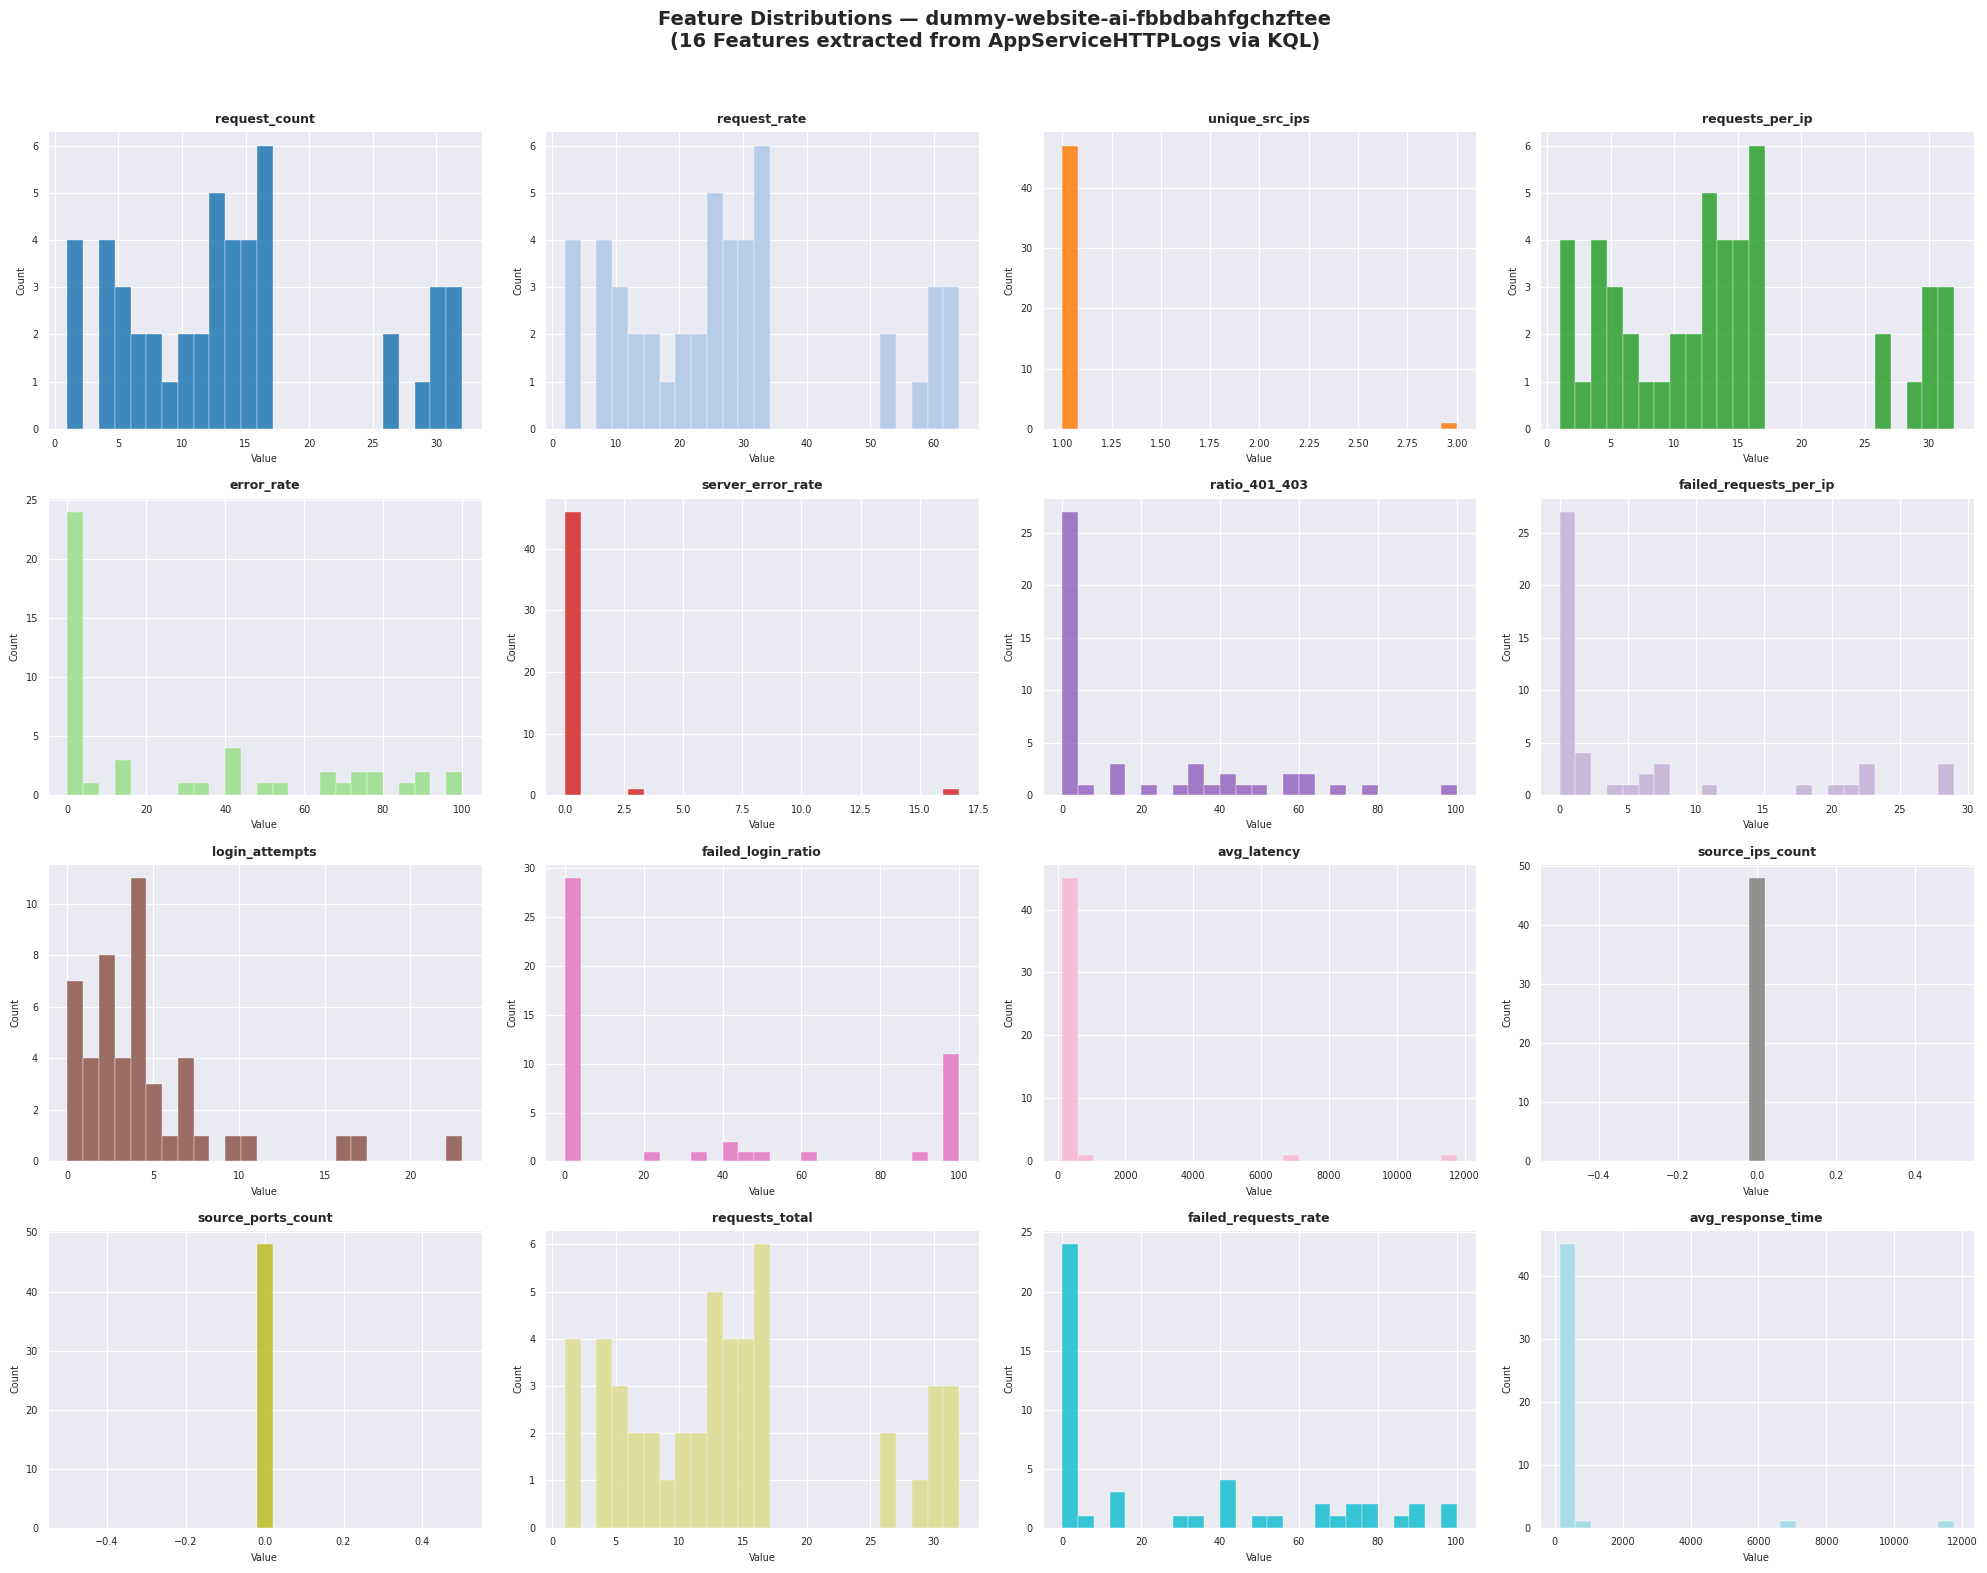

In [6]:
df_feat = df_raw[FEATURE_COLS].copy()

print('=' * 60)
print('📋 DATASET OVERVIEW')
print('=' * 60)
print(f'  Shape        : {df_feat.shape}')
print(f'  Memory usage : {df_feat.memory_usage(deep=True).sum()/1024:.1f} KB')
print(f'  NaN values   : {df_feat.isnull().sum().sum()}')
print(f'  Data source  : Real Azure Monitor Log Analytics (KQL)')
print()
print('--- Feature Statistics ---')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df_feat.describe().round(3).to_string())

# ── Plot: Feature Distributions ──────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
colors = plt.cm.tab20(np.linspace(0, 1, len(FEATURE_COLS)))

for i, feat in enumerate(FEATURE_COLS):
    axes[i].hist(df_feat[feat].dropna(), bins=25,
                 color=colors[i], alpha=0.85,
                 edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=7)
    axes[i].set_ylabel('Count',  fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle(
    f'Feature Distributions — {WEBSITE_SHORT}\n'
    f'(16 Features extracted from AppServiceHTTPLogs via KQL)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 🧹 Step 6: Data Cleaning — NaN, Inf, Duplicates


In [7]:
print('🔧 Data Cleaning Pipeline')
print('-' * 50)

df_clean = df_feat.copy()

# 1. Replace Inf
inf_count = np.isinf(df_clean.select_dtypes(include=[np.number])).sum().sum()
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'  1. Inf values replaced     : {inf_count:,}')

# 2. Fill NaN with 0
nan_count = df_clean.isnull().sum().sum()
df_clean.fillna(0, inplace=True)
print(f'  2. NaN values filled (→0)  : {nan_count:,}')

# 3. Drop duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'  3. Duplicate rows removed  : {before - len(df_clean):,}')

# 4. Force numeric
for col in FEATURE_COLS:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)
print(f'  4. All columns cast to numeric')

print('-' * 50)
print(f'  ✅ Clean shape : {df_clean.shape}')
print(f'  ✅ Remaining NaN : {df_clean.isnull().sum().sum()}')
print(f'  ✅ Remaining Inf : {np.isinf(df_clean.values).sum()}')

# Missing value chart
nan_per_col = df_feat.isnull().sum()
if nan_per_col.sum() > 0:
    plt.figure(figsize=(12, 4))
    nan_per_col[nan_per_col > 0].sort_values().plot(kind='barh', color='#ef4444')
    plt.title('Missing Values per Column (before cleaning)', fontweight='bold')
    plt.xlabel('NaN Count')
    plt.tight_layout()
    plt.show()
else:
    print('\n  ✅ No missing values in any feature column')


🔧 Data Cleaning Pipeline
--------------------------------------------------
  1. Inf values replaced     : 0
  2. NaN values filled (→0)  : 0
  3. Duplicate rows removed  : 0
  4. All columns cast to numeric
--------------------------------------------------
  ✅ Clean shape : (48, 16)
  ✅ Remaining NaN : 0
  ✅ Remaining Inf : 0

  ✅ No missing values in any feature column


## ⚙️ Step 7: Feature Scaling — StandardScaler


✅ Feature scaling complete (StandardScaler)
   Input shape : (48, 16)
   Mean        : -0.00000000  ← target ≈ 0
   Std         : 0.93541435   ← target ≈ 1


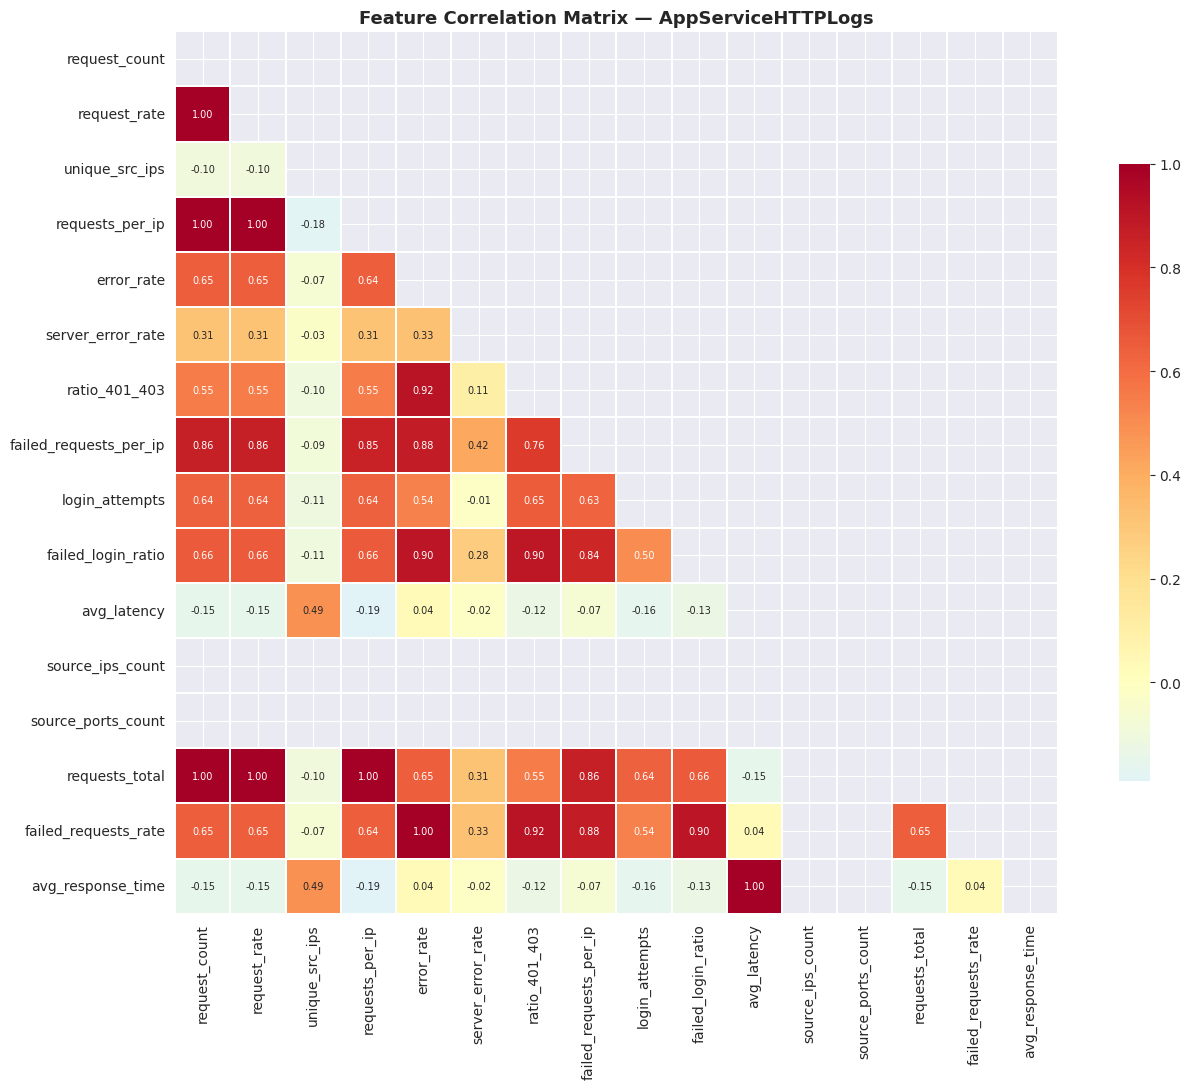

In [8]:
X = df_clean[FEATURE_COLS].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Feature scaling complete (StandardScaler)')
print(f'   Input shape : {X.shape}')
print(f'   Mean        : {X_scaled.mean():.8f}  ← target ≈ 0')
print(f'   Std         : {X_scaled.std():.8f}   ← target ≈ 1')

# Correlation heatmap
plt.figure(figsize=(14, 11))
corr = df_clean[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0,
    annot_kws={'size': 7},
    square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
plt.title('Feature Correlation Matrix — AppServiceHTTPLogs',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##  Step 8: Create Target Labels (Rule-Based Pseudo Labels)


In [9]:
print('🎯 Creating Rule-Based Pseudo Labels...')
print()

# Initialize anomaly score
anomaly_score = np.zeros(len(df_clean), dtype=int)

# =========================
# A. Traffic Intensity Rules
# =========================
rule_request_rate   = df_clean['request_rate'] >= 5
rule_request_count  = df_clean['request_count'] >= 50
rule_requests_per_ip = df_clean['requests_per_ip'] >= 40

# =========================
# B. Error / Auth Abuse Rules
# =========================
rule_error_rate         = df_clean['error_rate'] >= 40
rule_ratio_401_403      = df_clean['ratio_401_403'] >= 20
rule_failed_requests_ip = df_clean['failed_requests_per_ip'] >= 10

# =========================
# C. Login Abuse Rules
# =========================
rule_login_attempts    = df_clean['login_attempts'] >= 15
rule_failed_login_ratio = df_clean['failed_login_ratio'] >= 50

# =========================
# D. Rare Severe Indicator
# =========================
rule_server_error = df_clean['server_error_rate'] > 0

# Add points for each triggered rule
anomaly_score += rule_request_rate.astype(int)
anomaly_score += rule_request_count.astype(int)
anomaly_score += rule_requests_per_ip.astype(int)

anomaly_score += rule_error_rate.astype(int)
anomaly_score += rule_ratio_401_403.astype(int)
anomaly_score += rule_failed_requests_ip.astype(int)

anomaly_score += rule_login_attempts.astype(int)
anomaly_score += rule_failed_login_ratio.astype(int)

anomaly_score += rule_server_error.astype(int)

# Final pseudo labels:
# 0 = normal, 1 = anomaly
y_true = (anomaly_score >= 3).astype(int)

attack_count = int(y_true.sum())
normal_count = len(y_true) - attack_count

print('✅ Pseudo labels created using fixed threshold anomaly scoring')
print()

print('  Rules Applied:')
print('    • request_rate ≥ 5')
print('    • request_count ≥ 50')
print('    • requests_per_ip ≥ 40')
print('    • error_rate ≥ 40%')
print('    • ratio_401_403 ≥ 20%')
print('    • failed_requests_per_ip ≥ 10')
print('    • login_attempts ≥ 15')
print('    • failed_login_ratio ≥ 50%')
print('    • server_error_rate > 0')
print()
print('  Label Rule:')
print('    • anomaly_score ≥ 3  →  Anomaly')
print('    • anomaly_score < 3  →  Normal')
print()

print('  Results:')
print(f'    🟢 Normal   : {normal_count:,}  ({normal_count/len(y_true)*100:.2f}%)')
print(f'    🔴 Anomaly  : {attack_count:,}  ({attack_count/len(y_true)*100:.2f}%)')
print()

# Optional inspection table
rule_debug = pd.DataFrame({
    'request_count': df_clean['request_count'],
    'request_rate': df_clean['request_rate'],
    'requests_per_ip': df_clean['requests_per_ip'],
    'error_rate': df_clean['error_rate'],
    'ratio_401_403': df_clean['ratio_401_403'],
    'failed_requests_per_ip': df_clean['failed_requests_per_ip'],
    'login_attempts': df_clean['login_attempts'],
    'failed_login_ratio': df_clean['failed_login_ratio'],
    'server_error_rate': df_clean['server_error_rate'],
    'anomaly_score': anomaly_score,
    'pseudo_label': y_true
})

print('📋 Rule Debug Preview:')
display(rule_debug)

HAS_LABELS = True

🎯 Creating Rule-Based Pseudo Labels...

✅ Pseudo labels created using fixed threshold anomaly scoring

  Rules Applied:
    • request_rate ≥ 5
    • request_count ≥ 50
    • requests_per_ip ≥ 40
    • error_rate ≥ 40%
    • ratio_401_403 ≥ 20%
    • failed_requests_per_ip ≥ 10
    • login_attempts ≥ 15
    • failed_login_ratio ≥ 50%
    • server_error_rate > 0

  Label Rule:
    • anomaly_score ≥ 3  →  Anomaly
    • anomaly_score < 3  →  Normal

  Results:
    🟢 Normal   : 32  (66.67%)
    🔴 Anomaly  : 16  (33.33%)

📋 Rule Debug Preview:


,request_count,request_rate,requests_per_ip,error_rate,ratio_401_403,failed_requests_per_ip,login_attempts,failed_login_ratio,server_error_rate,anomaly_score,pseudo_label
0,8,16,2.6667,12.5000,0.0000,0.3333,1,0.0000,0.0000,1,0
1,16,32,16.0000,6.2500,6.2500,1.0000,3,33.3333,0.0000,1,0
2,4,8,4.0000,50.0000,50.0000,2.0000,2,100.0000,0.0000,4,1
3,7,14,7.0000,14.2857,14.2857,1.0000,2,50.0000,0.0000,2,0
4,5,10,5.0000,40.0000,0.0000,2.0000,0,0.0000,0.0000,2,0
5,1,2,1.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0
6,17,34,17.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,1,0
7,5,10,5.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,1,0
8,2,4,2.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0
9,2,4,2.0000,0.0000,0.0000,0.0000,1,0.0000,0.0000,0,0


##  Step 9: Train Isolation Forest (200 Trees, Auto Contamination)


In [10]:
# Auto-compute contamination from true attack ratio
if HAS_LABELS and y_true is not None:
    attack_ratio  = float(y_true.sum()) / len(y_true)
    contamination = round(min(max(attack_ratio, 0.01), 0.5), 3)
    print(f'   Attack ratio in dataset : {attack_ratio:.4f}  ({attack_ratio*100:.2f}%)')
else:
    contamination = 0.05
    print('   No labels → using default contamination = 0.05')

print(f'\n🌲 Training Isolation Forest...')
print(f'   n_estimators  : 200')
print(f'   contamination : {contamination}')
print(f'   max_samples   : auto')
print(f'   n_jobs        : -1  (all CPU cores)')
print(f'   random_state  : 42')
print(f'   n_features    : {X_scaled.shape[1]}')
print(f'   n_samples     : {X_scaled.shape[0]:,}')

iso_forest = IsolationForest(
    n_estimators  = 200,
    contamination = contamination,
    max_samples   = 'auto',
    max_features  = 1.0,
    bootstrap     = False,
    n_jobs        = -1,
    random_state  = 42
)

t0 = time.time()
iso_forest.fit(X_scaled)
train_sec = time.time() - t0

print(f'\n✅ Training complete in {train_sec:.2f} seconds')


   Attack ratio in dataset : 0.3333  (33.33%)

🌲 Training Isolation Forest...
   n_estimators  : 200
   contamination : 0.333
   max_samples   : auto
   n_jobs        : -1  (all CPU cores)
   random_state  : 42
   n_features    : 16
   n_samples     : 48

✅ Training complete in 0.29 seconds


##### **Generate Predictions & Anomaly Scores**

In [22]:
print('=' * 60)
print('🔍 GENERATING PREDICTIONS')
print('=' * 60)

# Raw Isolation Forest outputs:
#   1  = normal
#  -1  = anomaly
raw_pred = iso_forest.predict(X_scaled)

# Convert to project-friendly format:
#   0 = normal
#   1 = anomaly
y_pred = np.where(raw_pred == -1, 1, 0)

# Anomaly scores (lower = more anomalous)
anomaly_scores = iso_forest.decision_function(X_scaled)

# Counts
n_attacks = int((y_pred == 1).sum())
n_normal  = int((y_pred == 0).sum())

print('✅ Predictions generated successfully')
print(f'   Total samples   : {len(y_pred):,}')
print(f'   Normal predicted: {n_normal:,}  ({n_normal/len(y_pred)*100:.2f}%)')
print(f'   Anomaly predicted: {n_attacks:,}  ({n_attacks/len(y_pred)*100:.2f}%)')

print(f'\n   Min score : {anomaly_scores.min():.6f}')
print(f'   Max score : {anomaly_scores.max():.6f}')
print(f'   Mean score: {anomaly_scores.mean():.6f}')

🔍 GENERATING PREDICTIONS
✅ Predictions generated successfully
   Total samples   : 48
   Normal predicted: 32  (66.67%)
   Anomaly predicted: 16  (33.33%)

   Min score : -0.167027
   Max score : 0.121157
   Mean score: 0.020614


## 📊 Step 11: Evaluate — Precision, Recall, F1, ROC-AUC, Confusion Matrix


In [12]:
print('=' * 60)
print('📊 MODEL EVALUATION')
print('=' * 60)

accuracy = precision = recall = f1 = roc_auc = None
cm = None

if HAS_LABELS and y_true is not None and len(y_true) == len(y_pred):

    print('\n📋 Classification Report:')
    print(classification_report(
        y_true, y_pred,
        target_names=['Normal (0)', 'Anomaly (1)'],
        digits=4
    ))

    cm            = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    roc_auc   = roc_auc_score(y_true, -anomaly_scores)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy  = (tp + tn) / len(y_true)

    print('\n📈 Summary Metrics:')
    print(f'   Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
    print(f'   Precision : {precision:.4f}')
    print(f'   Recall    : {recall:.4f}')
    print(f'   F1-Score  : {f1:.4f}')
    print(f'   ROC-AUC   : {roc_auc:.4f}')
    print(f'\n   TP={tp}  |  TN={tn}  |  FP={fp}  |  FN={fn}')

else:
    print('\n  ℹ️  No labels available.')
    print(f'  Total records   : {len(y_pred):,}')
    print(f'  Anomalies found : {n_attacks:,}  ({n_attacks/len(y_pred)*100:.2f}%)')
    print(f'  Normal traffic  : {n_normal:,}  ({n_normal/len(y_pred)*100:.2f}%)')


📊 MODEL EVALUATION

📋 Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.9062    0.9062    0.9062        32
 Anomaly (1)     0.8125    0.8125    0.8125        16

    accuracy                         0.8750        48
   macro avg     0.8594    0.8594    0.8594        48
weighted avg     0.8750    0.8750    0.8750        48


📈 Summary Metrics:
   Accuracy  : 0.8750  (87.50%)
   Precision : 0.8125
   Recall    : 0.8125
   F1-Score  : 0.8125
   ROC-AUC   : 0.9121

   TP=13  |  TN=29  |  FP=3  |  FN=3


## 📈 Step 12: Six Visualisations


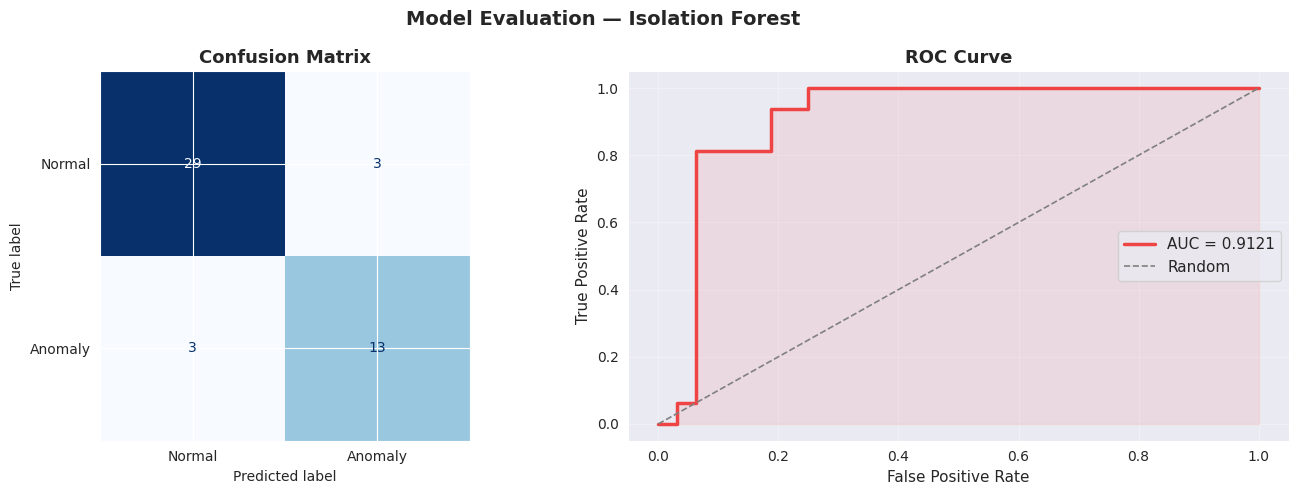

In [13]:
# ══════════════════════════════════════════════════════════════
#  VIZ 1 + 2: Confusion Matrix  &  ROC Curve
# ══════════════════════════════════════════════════════════════
if HAS_LABELS and cm is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Anomaly']
    ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

    fpr, tpr, _ = roc_curve(y_true, -anomaly_scores)
    axes[1].plot(fpr, tpr, color='#ef4444', lw=2.5, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'gray', ls='--', lw=1.2, label='Random')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#ef4444')
    axes[1].set_xlabel('False Positive Rate', fontsize=11)
    axes[1].set_ylabel('True Positive Rate', fontsize=11)
    axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Model Evaluation — Isolation Forest', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    # No labels: score histogram instead
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(anomaly_scores, bins=35, color='#3b82f6',
                 alpha=0.8, edgecolor='white')
    axes[0].axvline(
        np.percentile(anomaly_scores, contamination * 100),
        color='red', ls='--', lw=2, label='Decision boundary'
    )
    axes[0].set_title('Anomaly Score Histogram', fontweight='bold')
    axes[0].set_xlabel('Anomaly Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    axes[1].scatter(range(len(anomaly_scores)), anomaly_scores,
                    c=y_pred, cmap='RdYlGn_r', s=20, alpha=0.7)
    axes[1].set_title('Score per Record  (Red = Anomaly)', fontweight='bold')
    axes[1].set_xlabel('Record Index')
    axes[1].set_ylabel('Anomaly Score')

    plt.suptitle('Anomaly Score Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


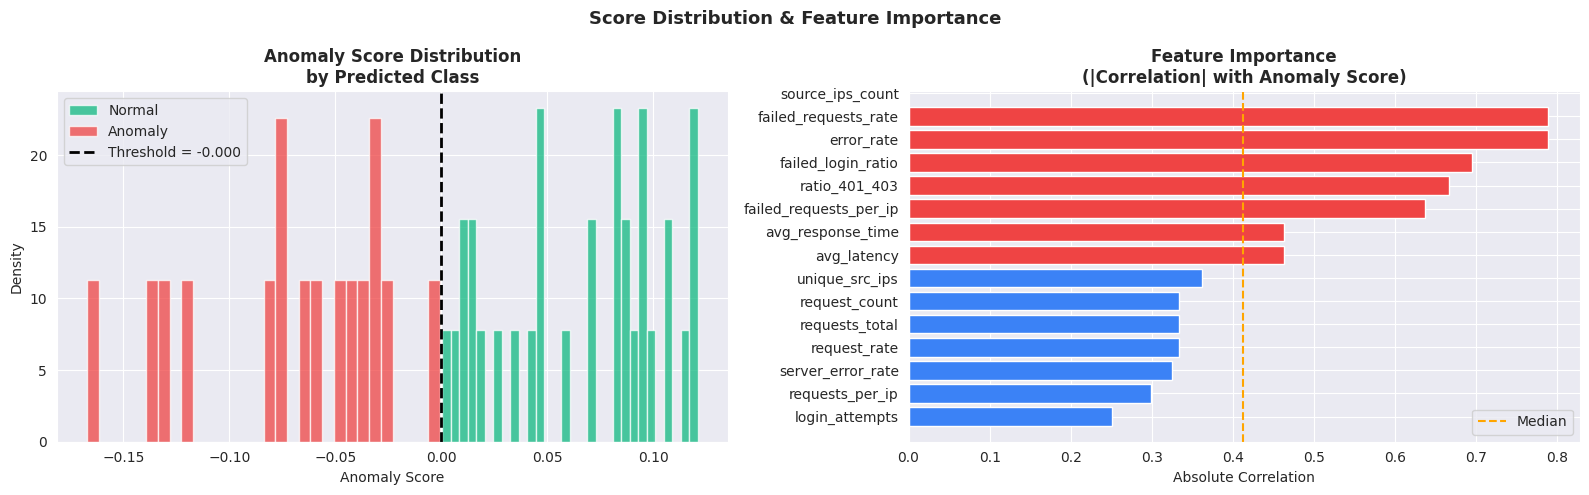

In [14]:
# ══════════════════════════════════════════════════════════════
#  VIZ 3 + 4: Score Distribution  &  Feature Importance
# ══════════════════════════════════════════════════════════════
boundary = np.percentile(anomaly_scores, contamination * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score distribution
axes[0].hist(anomaly_scores[y_pred == 0], bins=30, color='#10b981',
             alpha=0.75, density=True, label='Normal', edgecolor='white')
axes[0].hist(anomaly_scores[y_pred == 1], bins=30, color='#ef4444',
             alpha=0.75, density=True, label='Anomaly', edgecolor='white')
axes[0].axvline(boundary, color='black', ls='--', lw=2,
                label=f'Threshold = {boundary:.3f}')
axes[0].set_title('Anomaly Score Distribution\nby Predicted Class',
                  fontweight='bold')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Feature importance (correlation with anomaly score)
feat_corr = pd.Series(
    [abs(np.corrcoef(X_scaled[:, i], anomaly_scores)[0, 1])
     for i in range(X_scaled.shape[1])],
    index=FEATURE_COLS
).sort_values(ascending=True)

bar_colors = [
    '#ef4444' if v > feat_corr.median() else '#3b82f6'
    for v in feat_corr.values
]
axes[1].barh(feat_corr.index, feat_corr.values,
             color=bar_colors, edgecolor='white')
axes[1].axvline(feat_corr.median(), color='orange',
                ls='--', lw=1.5, label='Median')
axes[1].set_title('Feature Importance\n(|Correlation| with Anomaly Score)',
                  fontweight='bold')
axes[1].set_xlabel('Absolute Correlation')
axes[1].legend()

plt.suptitle('Score Distribution & Feature Importance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [16]:
# Timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Directory
MODEL_DIR = './luminous_model'
os.makedirs(MODEL_DIR, exist_ok=True)

# Paths
MODEL_PATH  = f'{MODEL_DIR}/iso_forest_{timestamp}.pkl'
SCALER_PATH = f'{MODEL_DIR}/scaler_{timestamp}.pkl'
FEATS_PATH  = f'{MODEL_DIR}/feature_cols_{timestamp}.json'
META_PATH   = f'{MODEL_DIR}/metadata_{timestamp}.json'

# Save Model & Scaler
joblib.dump(iso_forest, MODEL_PATH,  compress=3)
joblib.dump(scaler,     SCALER_PATH, compress=3)

# Save Feature Columns
with open(FEATS_PATH, 'w') as fh:
    json.dump(FEATURE_COLS, fh, indent=2)

# Minimal Metadata
metadata = {
    "saved_at": datetime.now().isoformat(),
    "algorithm": "IsolationForest",
    "n_features": len(FEATURE_COLS),
    "features": FEATURE_COLS
}

with open(META_PATH, 'w') as fh:
    json.dump(metadata, fh, indent=2)

print("✅ Model artifacts saved:")
print("   ", MODEL_PATH)
print("   ", SCALER_PATH)
print("   ", FEATS_PATH)
print("   ", META_PATH)

✅ Model artifacts saved:
    ./luminous_model/iso_forest_20260407_152432.pkl
    ./luminous_model/scaler_20260407_152432.pkl
    ./luminous_model/feature_cols_20260407_152432.json
    ./luminous_model/metadata_20260407_152432.json


**Results Table**

In [31]:
print('=' * 60)
print('📋 BUILDING FINAL ANOMALY RESULTS TABLE')
print('=' * 60)

# Create readable prediction labels
prediction_label = np.where(y_pred == 1, 'Anomaly', 'Normal')

# Build results dataframe
df_results = df_clean.copy()

# Add model outputs
df_results['anomaly_score'] = anomaly_scores
df_results['prediction'] = prediction_label

# ------------------------------------------------------------
# Attach Source IP from df_raw (IMPORTANT)
# ------------------------------------------------------------
import ast

if 'source_ips' in df_raw.columns:
    def extract_ip(idx):
        ips = df_raw.iloc[idx]['source_ips']

        # If already list
        if isinstance(ips, list) and len(ips) > 0:
            return ips[0] if len(ips) == 1 else f"{ips[0]} (+{len(ips)-1})"

        # If string like '["1.1.1.1","2.2.2.2"]'
        if isinstance(ips, str):
            try:
                parsed = ast.literal_eval(ips)
                if isinstance(parsed, list) and len(parsed) > 0:
                    return parsed[0] if len(parsed) == 1 else f"{parsed[0]} (+{len(parsed)-1})"
            except:
                return ips  # fallback to raw string

        return "N/A"

    df_results['Source_IP'] = [extract_ip(i) for i in range(len(df_results))]
else:
    df_results['Source_IP'] = "N/A"

# ------------------------------------------------------------
# Severity logic
# ------------------------------------------------------------
def assign_severity(row):
    if row['prediction'] == 'Normal':
        return 'Normal'
    
    if (
        row['failed_login_ratio'] >= 70 or
        row['error_rate'] >= 60 or
        row['login_attempts'] >= 20
    ):
        return 'Critical'
    
    elif (
        row['failed_login_ratio'] >= 40 or
        row['error_rate'] >= 30 or
        row['login_attempts'] >= 10
    ):
        return 'High'
    
    else:
        return 'Medium'

# ------------------------------------------------------------
# Reason logic
# ------------------------------------------------------------
def assign_reason(row):
    reasons = []

    if row['failed_login_ratio'] >= 40:
        reasons.append('Brute Force Login')

    if row['error_rate'] >= 30:
        reasons.append('High Error Activity')

    if row['ratio_401_403'] >= 20:
        reasons.append('Unauthorized Access')

    if row['request_count'] >= df_results['request_count'].quantile(0.90):
        reasons.append('Traffic Spike')

    if row['login_attempts'] >= 10:
        reasons.append('Abnormal Login Activity')

    if row['prediction'] == 'Normal':
        return 'Normal Activity'

    if len(reasons) == 0:
        return 'General Anomaly'
    
    if len(reasons) >= 2:
        return 'Multi-factor Attack'

    return reasons[0]

# Apply severity + reason
df_results['severity'] = df_results.apply(assign_severity, axis=1)
df_results['reason'] = df_results.apply(assign_reason, axis=1)

# Sort (most anomalous first)
df_results = df_results.sort_values(by='anomaly_score', ascending=True).reset_index(drop=True)

# ------------------------------------------------------------
# FINAL SIMPLIFIED DISPLAY (your requirement)
# ------------------------------------------------------------
DISPLAY_COLS = [
    'Source_IP',
    'request_count',
    'request_rate',
    'login_attempts',
    'prediction',
    'reason'
]

df_display = df_results[DISPLAY_COLS].rename(columns={
    'Source_IP': 'Source IP',
    'request_count': 'Requests',
    'request_rate': 'Request Rate',
    'login_attempts': 'Login Attempts',
    'prediction': 'Prediction',
    'reason': 'Reason'
})

print('✅ Final anomaly results table created')
print(f'   Total rows      : {len(df_results):,}')
print(f'   Normal rows     : {(df_results["prediction"] == "Normal").sum():,}')
print(f'   Anomaly rows    : {(df_results["prediction"] == "Anomaly").sum():,}')
print()

print('🔝 Top Results Preview:')
display(df_display.head(10))

📋 BUILDING FINAL ANOMALY RESULTS TABLE
✅ Final anomaly results table created
   Total rows      : 48
   Normal rows     : 32
   Anomaly rows    : 16

🔝 Top Results Preview:


,Source IP,Requests,Request Rate,Login Attempts,Prediction,Reason
0,104.211.81.64 (+2),8,16,1,Anomaly,General Anomaly
1,120.60.98.141,30,60,4,Anomaly,Multi-factor Attack
2,120.60.98.141,5,10,0,Anomaly,High Error Activity
3,120.60.98.141,7,14,7,Anomaly,Multi-factor Attack
4,120.60.98.141,27,54,17,Anomaly,Multi-factor Attack
5,120.60.98.141,31,62,23,Anomaly,Multi-factor Attack
6,120.60.98.141,32,64,8,Anomaly,Multi-factor Attack
7,120.60.98.141,30,60,4,Anomaly,Multi-factor Attack
8,157.51.115.11,4,8,2,Anomaly,Multi-factor Attack
9,120.60.98.141,8,16,1,Anomaly,Multi-factor Attack


In [35]:
from datetime import datetime

# Save final website-ready anomaly results
website_results_file = "latest_anomaly_results.csv"

# Keep only required columns for website
df_website = df_results.copy()

FINAL_COLS = [
    'Source_IP',
    'request_count',
    'request_rate',
    'login_attempts',
    'prediction',
    'reason'
]

df_website = df_website[FINAL_COLS].rename(columns={
    'Source_IP': 'source_ip',
    'request_count': 'requests',
    'request_rate': 'request_rate',
    'login_attempts': 'login_attempts',
    'prediction': 'prediction',
    'reason': 'reason'
})

df_website.to_csv(website_results_file, index=False)

print("✅ Website anomaly results CSV created")
print("📁 File:", website_results_file)
print()

✅ Website anomaly results CSV created
📁 File: latest_anomaly_results.csv



In [36]:
from azure.storage.blob import BlobServiceClient

# Blob details
container_name = "logsgenerated"
blob_name = "dashboard/latest_anomaly_results.csv"

# Upload latest anomaly results CSV to Blob
blob_service_client = BlobServiceClient.from_connection_string(AZURE_CONNECTION_STRING)
blob_client = blob_service_client.get_blob_client(container=container_name, blob=blob_name)

with open(website_results_file, "rb") as data:
    blob_client.upload_blob(data, overwrite=True)

print("✅ Anomaly results uploaded to Azure Blob Storage")
print(f"📦 Container : {container_name}")
print(f"📄 Blob path : {blob_name}")

✅ Anomaly results uploaded to Azure Blob Storage
📦 Container : logsgenerated
📄 Blob path : dashboard/latest_anomaly_results.csv
